1. Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

2. Define and Initialize Dataset

In [ ]:
# Create sample dataset
X, y = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)

print("Dataset Shape:", X.shape)
print("First 10 Data Points:")
print(X[:10])

Dataset Shape: (300, 2)
First 10 Data Points:
[[ 0.65880058 -0.35596254]
 [ 1.98630199 -0.13348998]
 [-0.11162344  0.4550811 ]
 [ 0.90500816  0.26679823]
 [ 1.18161893 -0.49496507]
 [ 1.02169091 -0.44027265]
 [ 0.39841083 -0.26265822]
 [-0.581296    0.71952393]
 [ 0.92036446  0.06419018]
 [ 0.19254572  0.00435812]]


3. Visualize the Original Dataset

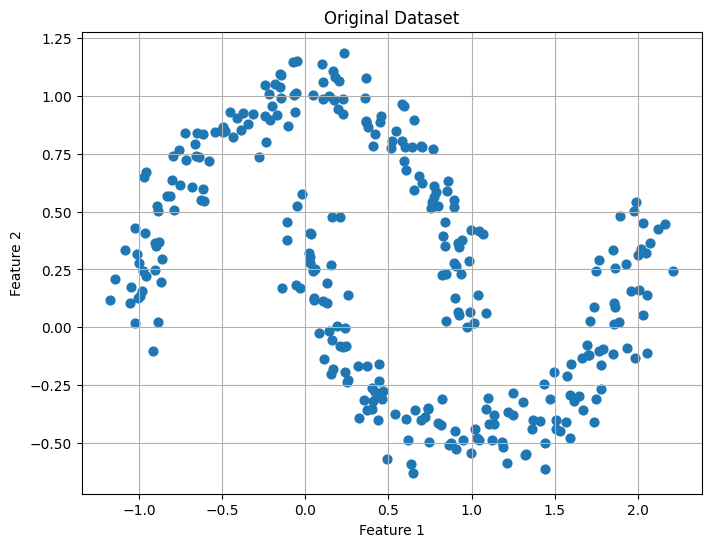

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=40
)

plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

plt.show()

4. Define DBSCAN Parameters

In [ ]:
# DBSCAN parameters
eps = 0.20
min_samples = 5

print("Epsilon (eps):", eps)
print("Minimum Samples:", min_samples)

Epsilon (eps): 0.2
Minimum Samples: 5


5. Demonstrate the eps Neighborhood

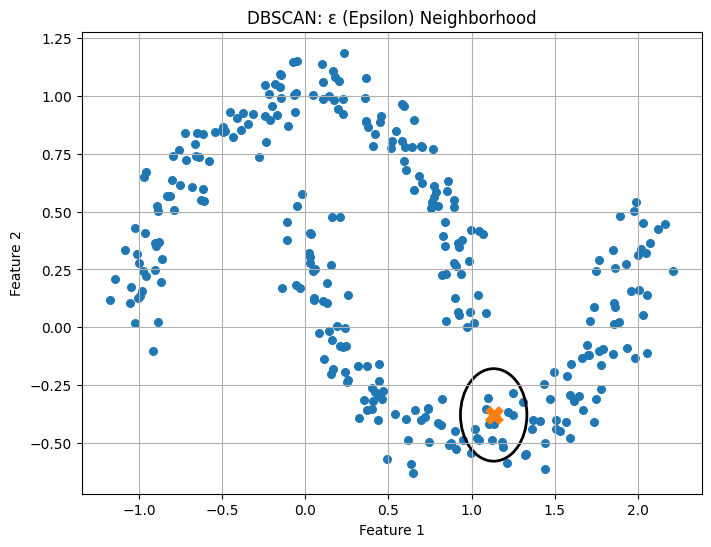

In [ ]:
from matplotlib.patches import Circle

# Select a point
point_index = 100
point = X[point_index]

plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], s=30)

# Highlight selected point
plt.scatter(
    point[0],
    point[1],
    s=150,
    marker='X'
)

# Draw eps neighborhood
circle = Circle(
    (point[0], point[1]),
    eps,
    fill=False,
    linewidth=2
)

plt.gca().add_patch(circle)

plt.title("DBSCAN: ε (Epsilon) Neighborhood")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

plt.show()

6. Identify Core, Border and Noise Points

In [ ]:
# Fit DBSCAN
dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

labels = dbscan.fit_predict(X)

# Identify core samples
core_indices = dbscan.core_sample_indices_
core_mask = np.zeros(len(X), dtype=bool)
core_mask[core_indices] = True

# Noise points have label -1
noise_mask = labels == -1

# Border points are non-core points that are not noise
border_mask = (~core_mask) & (~noise_mask)

print("Core Points:", np.sum(core_mask))
print("Border Points:", np.sum(border_mask))
print("Noise Points:", np.sum(noise_mask))

Core Points: 295
Border Points: 5
Noise Points: 0


7. Visualize Core, Border and Noise Points

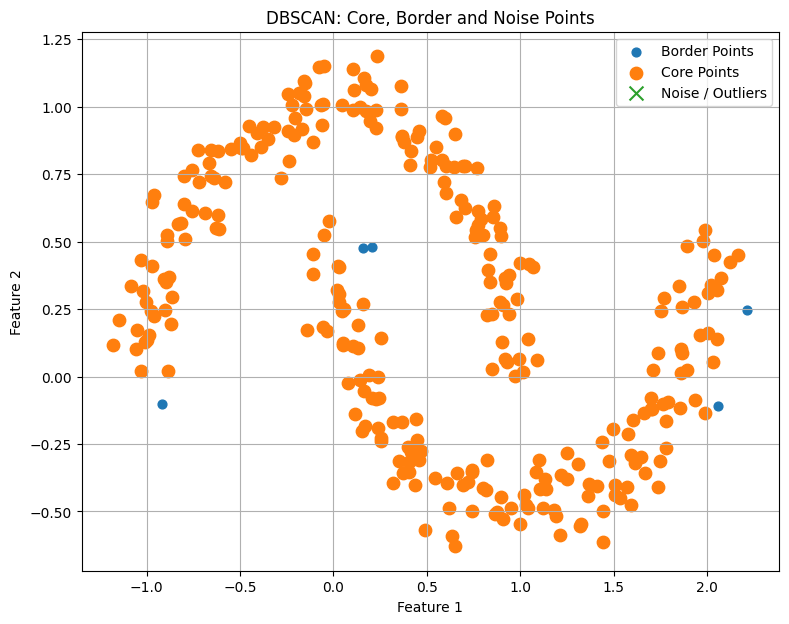

In [ ]:
plt.figure(figsize=(9, 7))

# Border points
plt.scatter(
    X[border_mask, 0],
    X[border_mask, 1],
    s=40,
    label="Border Points"
)

# Core points
plt.scatter(
    X[core_mask, 0],
    X[core_mask, 1],
    s=80,
    marker='o',
    label="Core Points"
)

# Noise points
plt.scatter(
    X[noise_mask, 0],
    X[noise_mask, 1],
    s=100,
    marker='x',
    label="Noise / Outliers"
)

plt.title("DBSCAN: Core, Border and Noise Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()

8. Show the Clustering Process

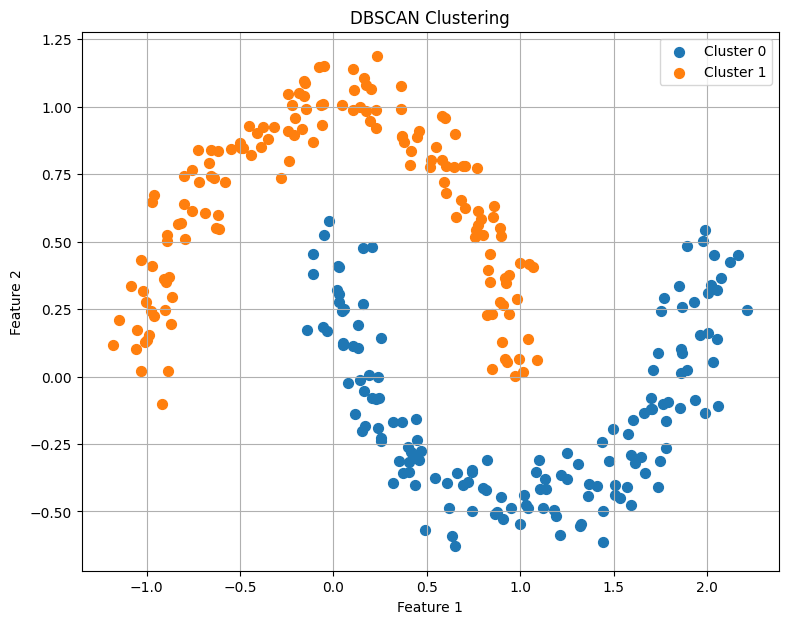

In [ ]:
plt.figure(figsize=(9, 7))

unique_labels = set(labels)

for label in unique_labels:

    # Noise
    if label == -1:
        mask = labels == label

        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            marker='x',
            s=100,
            label="Noise"
        )

    else:
        mask = labels == label

        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            s=50,
            label=f"Cluster {label}"
        )

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()

9. Compare Original Dataset vs DBSCAN Result

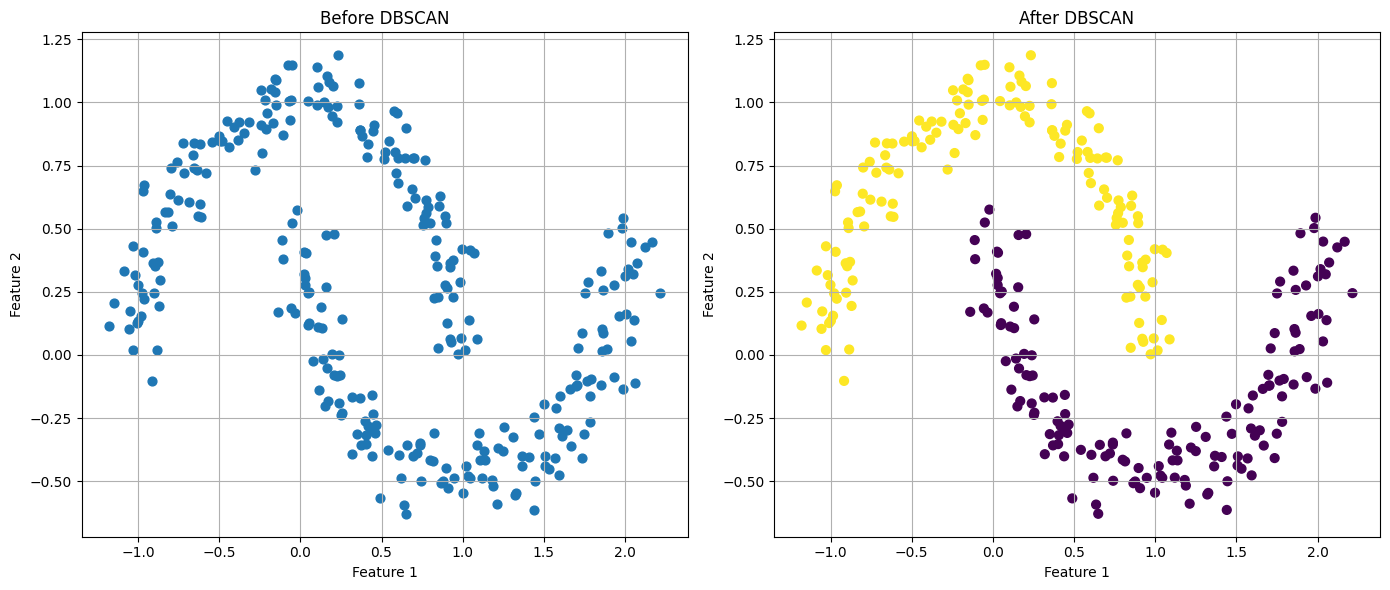

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original dataset
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    s=40
)

axes[0].set_title("Before DBSCAN")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(True)

# DBSCAN result
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=40
)

axes[1].set_title("After DBSCAN")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

10. Display Cluster Information

In [ ]:
# Number of clusters excluding noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise points
n_noise = list(labels).count(-1)

print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)

for cluster in sorted(set(labels)):
    if cluster == -1:
        continue

    count = np.sum(labels == cluster)
    print(f"Cluster {cluster}: {count} points")

Number of Clusters: 2
Number of Noise Points: 0
Cluster 0: 150 points
Cluster 1: 150 points
